In [1]:
import os
import pandas as pd

rows = []
processed_dir = "/kaggle/input/datasets/snglrty44/mri-labels-classification/processed"

for label in os.listdir(processed_dir):
    label_dir = os.path.join(processed_dir, label)
    if not os.path.isdir(label_dir):
        continue
    for fname in os.listdir(label_dir):
        if not fname.endswith(".png"):
            continue
        path = os.path.join(label_dir, fname)
        subject_id = fname.split("_slice")[0]
        rows.append({"path": path, "label": label, "subject_id": subject_id})

manifest = pd.DataFrame(rows)
manifest.to_csv("manifest.csv", index=False)

print(manifest.head())
print(f"Total: {len(manifest)} rows")
print(f"Subjects: {manifest['subject_id'].nunique()} unique")

                                                path label  \
0  /kaggle/input/datasets/snglrty44/mri-labels-cl...   t2w   
1  /kaggle/input/datasets/snglrty44/mri-labels-cl...   t2w   
2  /kaggle/input/datasets/snglrty44/mri-labels-cl...   t2w   
3  /kaggle/input/datasets/snglrty44/mri-labels-cl...   t2w   
4  /kaggle/input/datasets/snglrty44/mri-labels-cl...   t2w   

            subject_id  
0  ds000221_sub-010035  
1  ds000221_sub-010039  
2  ds000221_sub-010017  
3  ds000221_sub-010036  
4  ds000221_sub-010029  
Total: 1250 rows
Subjects: 81 unique


In [2]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupShuffleSplit

le = LabelEncoder()
manifest['label_idx'] = le.fit_transform(manifest['label'])

gss1 = GroupShuffleSplit(n_splits= 1,test_size = 0.3, random_state = 42)
train_idx,temp_idx = next(gss1.split(manifest,groups = manifest['subject_id']))
train_df = manifest.iloc[train_idx]
temp_df = manifest.iloc[temp_idx]

gss2 = GroupShuffleSplit(n_splits= 1,test_size = 0.5, random_state = 42)
val_idx,test_idx = next(gss2.split(temp_df,groups = temp_df['subject_id']))
val_df = temp_df.iloc[val_idx]
test_df = temp_df.iloc[test_idx]

In [3]:
print(len(train_df), len(val_df), len(test_df))


865 195 190


In [4]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy
import torchvision.transforms as transforms

class MRIDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['path']).convert('RGB')
        label = row['label_idx']
        if self.transform:
            image = self.transform(image)
        return image, label

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = MRIDataset(train_df, transform=transform)
val_dataset = MRIDataset(val_df, transform=transform)
test_dataset = MRIDataset(test_df, transform=transform)

print(train_dataset[0][0].shape, train_dataset[0][1])

torch.Size([3, 224, 224]) 4


In [5]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)


images, labels = next(iter(train_loader))
print(images.shape, labels.shape)

torch.Size([32, 3, 224, 224]) torch.Size([32])


In [6]:
import torchvision.models as models
import torch.nn as nn

model = models.resnet18(pretrained=True)

# freeze layer1 and layer2
for name, param in model.named_parameters():
    if 'layer1' in name or 'layer2' in name:
        param.requires_grad = False

# replace FC head for 5 classes
model.fc = nn.Linear(model.fc.in_features, 5)

print(model.fc)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Linear(in_features=512, out_features=5, bias=True)


In [7]:
import wandb
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: rai4ayush (rai4ayush-personal) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [8]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
import numpy as np
print(torch.__version__)
print(np.__version__)


2.2.0+cu118
11.8
True
Tesla P100-PCIE-16GB
2.2.0+cu118
1.26.4


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import wandb
import numpy as np

os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
# class weights
class_counts = train_df['label_idx'].value_counts().sort_index().values
class_weights = 1.0 / class_counts
class_weights = torch.tensor(class_weights / class_weights.sum(), dtype=torch.float)

# device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
class_weights = class_weights.to(device)

# loss, optimizer
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# W&B init
wandb.init(project="brain-mri-classifier", config={
    "model": "resnet18",
    "lr": 1e-4,
    "batch_size": 32,
    "epochs": 30,
    "freeze": "layer1+layer2"
})

# early stopping
best_val_loss = float('inf')
patience = 5
patience_counter = 0

# training loop
for epoch in range(30):
    # train
    model.train()
    train_loss, correct, total = 0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    train_acc = correct / total
    train_loss /= len(train_loader)

    # val
    model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    val_acc = correct / total
    val_loss /= len(val_loader)

    # log
    wandb.log({"train_loss": train_loss, "train_acc": train_acc,
                "val_loss": val_loss, "val_acc": val_acc, "epoch": epoch+1})
    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

wandb.finish()

Epoch 1 | Train Loss: 0.4691 Acc: 0.8694 | Val Loss: 0.1030 Acc: 0.9795
Epoch 2 | Train Loss: 0.1037 Acc: 0.9908 | Val Loss: 0.0208 Acc: 0.9949
Epoch 3 | Train Loss: 0.0802 Acc: 0.9965 | Val Loss: 0.0161 Acc: 0.9949
Epoch 4 | Train Loss: 0.0764 Acc: 0.9965 | Val Loss: 0.0134 Acc: 0.9949
Epoch 5 | Train Loss: 0.0893 Acc: 0.9965 | Val Loss: 0.0097 Acc: 1.0000
Epoch 6 | Train Loss: 0.0963 Acc: 0.9965 | Val Loss: 0.0092 Acc: 0.9949
Epoch 7 | Train Loss: 0.0580 Acc: 0.9977 | Val Loss: 0.0083 Acc: 0.9949
Epoch 8 | Train Loss: 0.0960 Acc: 0.9965 | Val Loss: 0.0087 Acc: 0.9949
Epoch 9 | Train Loss: 0.0759 Acc: 0.9965 | Val Loss: 0.0063 Acc: 1.0000
Epoch 10 | Train Loss: 0.0747 Acc: 0.9965 | Val Loss: 0.0122 Acc: 0.9949
Epoch 11 | Train Loss: 0.0652 Acc: 0.9965 | Val Loss: 0.0085 Acc: 0.9949
Epoch 12 | Train Loss: 0.0864 Acc: 0.9965 | Val Loss: 0.0068 Acc: 1.0000
Epoch 13 | Train Loss: 0.0694 Acc: 0.9965 | Val Loss: 0.0077 Acc: 0.9949
Epoch 14 | Train Loss: 0.0710 Acc: 0.9965 | Val Loss: 0.0062

epoch,▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇██
train_acc,▁███████████████████████████
train_loss,█▂▁▁▂▂▁▂▁▁▁▂▁▁▂▁▁▁▁▁▁▂▂▁▁▂▁▁
val_acc,▁▆▆▆█▆▆▆█▆▆█▆█▆█▆████▆██▅▆▆█
val_loss,█▂▂▂▁▁▁▁▁▂▁▁▁▁▁▁▂▁▁▁▁▁▁▁▂▁▁▁
epoch,28
train_acc,0.99653
train_loss,0.05802
val_acc,1
val_loss,0.00486


In [10]:
train_subjects = set(train_df['subject_id'])
val_subjects = set(val_df['subject_id'])
test_subjects = set(test_df['subject_id'])

print(train_subjects & val_subjects)
print(train_subjects & test_subjects)
print(val_subjects & test_subjects)

set()
set()
set()


In [11]:
print(manifest.groupby('subject_id')['label'].nunique().value_counts())

label
5    18
4    17
2    16
3    15
1    15
Name: count, dtype: int64


Macro F1: 1.0000
              precision    recall  f1-score   support

        bold       1.00      1.00      1.00        35
         dwi       1.00      1.00      1.00        35
       flair       1.00      1.00      1.00        40
         t1w       1.00      1.00      1.00        35
         t2w       1.00      1.00      1.00        45

    accuracy                           1.00       190
   macro avg       1.00      1.00      1.00       190
weighted avg       1.00      1.00      1.00       190



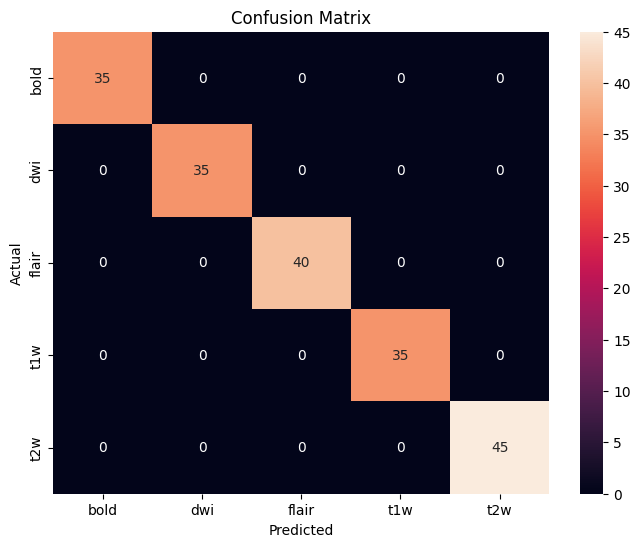

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# load best model
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# macro F1
f1 = f1_score(all_labels, all_preds, average='macro')
print(f"Macro F1: {f1:.4f}")

# per class report
print(classification_report(all_labels, all_preds, target_names=le.classes_))

# confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [13]:
import nibabel as nib
import numpy as np
from PIL import Image
import torch

def predict_nifti(nii_path, model, transform, le, device):
    # load nifti
    img = nib.load(nii_path)
    data = img.get_fdata()
    if data.ndim == 4:
        data = data[:, :, :, 0]
    
    mid = data.shape[2] // 2
    slice_2d = data[:, :, mid]
    
    #normalize
    mean = slice_2d.mean()
    std = slice_2d.std()
    slice_2d = (slice_2d - mean) / (std + 1e-8)
    
    # clip
    slice_2d = np.clip(slice_2d, -3, 3)
    
    # scale
    slice_2d = ((slice_2d + 3) / 6 * 255).astype(np.uint8)
    

    img_rgb = Image.fromarray(slice_2d).convert('RGB')
    
    # transform and predict
    tensor = transform(img_rgb).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        output = model(tensor)
        pred_idx = output.argmax(dim=1).item()
        pred_label = le.inverse_transform([pred_idx])[0]
    
    print(f"Predicted: {pred_label}")
    return pred_label

In [14]:
import subprocess
!pip install awscli
subprocess.run([
    "aws", "s3", "cp",
    "s3://openneuro.org/ds000114/sub-08/ses-test/func/sub-08_ses-test_task-fingerfootlips_bold.nii.gz",
    "test_bold.nii.gz",
    "--no-sign-request"
])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 66.8 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 90.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 28.3 MB/s eta 0:00:00
  Attempting uninstall: rsa
    Found existing installation: rsa 4.9.1
    Uninstalling rsa-4.9.1:
      Successfully uninstalled rsa-4.9.1
  Attempting uninstall: docutils
    Found existing installation: docutils 0.21.2
    Uninstalling docutils-0.21.2:
      Successfully uninstalled docutils-0.21.2
  Attempting uninstall: botocore
    Found existing installation: botocore 1.42.70
    Uninstalling botocore-1.42.70:
      Successfully uninstalled botocore-1.42.70
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
go

CompletedProcess(args=['aws', 's3', 'cp', 's3://openneuro.org/ds000114/sub-08/ses-test/func/sub-08_ses-test_task-fingerfootlips_bold.nii.gz', 'test_bold.nii.gz', '--no-sign-request'], returncode=0)

In [15]:
predict_nifti("test_bold.nii.gz", model, transform, le, device)

Predicted: bold


'bold'

In [16]:
subprocess.run([
    "aws", "s3", "cp",
    "s3://openneuro.org/ds000221/sub-010134/ses-01/anat/sub-010134_ses-01_T2w.nii.gz",
    "test_t2w.nii.gz",
    "--no-sign-request"
])

predict_nifti("test_t2w.nii.gz", model, transform, le, device)

download: s3://openneuro.org/ds000221/sub-010134/ses-01/anat/sub-010134_ses-01_T2w.nii.gz to ./test_t2w.nii.gz
Predicted: t2w


't2w'

In [19]:
subprocess.run([
    "aws", "s3", "cp",
    "s3://openneuro.org/ds004169/sub-0021/ses-01/anat/sub-0021_ses-01_T1w_defacemask.nii.gz",
    "test_t1w.nii.gz",
    "--no-sign-request"
])

predict_nifti("test_t1w.nii.gz", model, transform, le, device)

download: s3://openneuro.org/ds004169/sub-0021/ses-01/anat/sub-0021_ses-01_T1w_defacemask.nii.gz to ./test_t1w.nii.gz
Predicted: t1w


't1w'